# **E-Commerce Sales & Customer Insights**

# **Project Objective**
This project analyzes the Olist e-commerce dataset to evaluate sales performance and customer purchasing behavior. The main problem addressed is understanding revenue trends and order patterns using delivered orders only. The goal is to generate actionable business insights that support strategic decision-making.

import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load dataset

In [ ]:
df = pd.read_csv("master_orders.csv",
    sep=';',
    quotechar='"',
    na_values=["NULL"]   # convert SQL NULL to NaN
)

Convert date columns to datetime

In [ ]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

Check shape & nulls

In [ ]:
print(df.shape)
df.isnull().sum()

(118763, 14)


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_delivered_customer_date,3403
customer_city,0
customer_state,0
product_id,830
price,0
freight_value,0


Count of orders by status

In [ ]:
order_status_counts = df['order_status'].value_counts()
print(order_status_counts)

order_status
delivered      115361
shipped          1250
canceled          745
unavailable       650
processing        376
invoiced          373
created             5
approved            3
Name: count, dtype: int64


Keep only delivered orders

In [ ]:
df_delivered = df[df['order_status'] == 'delivered'].copy()

print(f"Original rows: {df.shape[0]}")
total_delivered_orders = df_delivered.shape[0]
print(f"Total Delivered Orders: {total_delivered_orders}")

Original rows: 118763
Total Delivered Orders: 115361


# **KPI SUMMARY**

In [ ]:
# Total Revenue (from delivered orders)
total_revenue = df_delivered['price'].sum()

# Average Order Value (AOV)
average_order_value = total_revenue / total_delivered_orders

print(f"Total Delivered Orders: {total_delivered_orders:,}")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Order Value (AOV): ${average_order_value:,.2f}")

Total Delivered Orders: 115,361
Total Revenue: $13,843,345.02
Average Order Value (AOV): $120.00


# **Order Status Distribution**

/tmp/ipython-input-179/2392851305.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


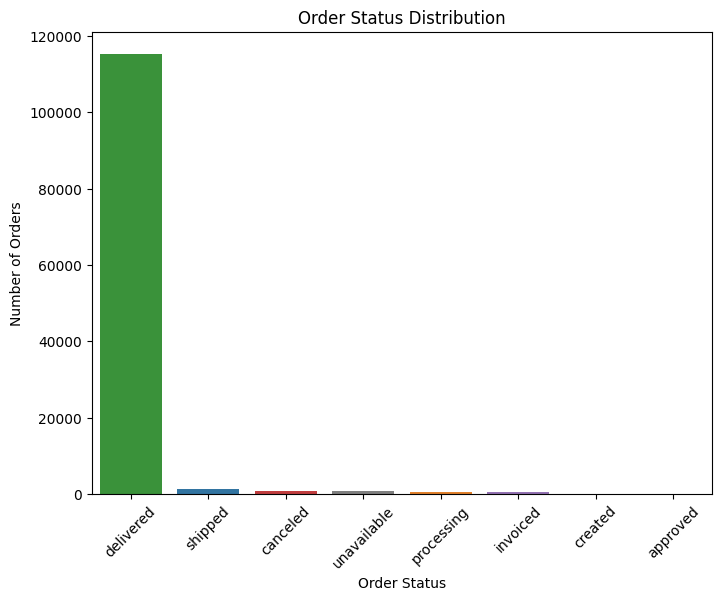

In [ ]:
# Count orders by status
order_status_counts = df['order_status'].value_counts().reset_index()
order_status_counts.columns = ['order_status', 'count']

# Plot
plt.figure(figsize=(8,6))
sns.barplot(
    data=order_status_counts,
    x='order_status',
    y='count',
    palette={'delivered':'#2ca02c', 'canceled':'#d62728', 'shipped':'#1f77b4', 'unavailable':'#7f7f7f',
             'invoiced':'#9467bd', 'processing':'#ff7f0e', 'created':'#8c564b', 'approved':'#e377c2'}
)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

Why: To understand the operational breakdown of all orders.
Insight: Majority of orders are delivered, but canceled and other statuses highlight fulfillment inefficiencies.
Business Value: Helps measure operational performance and identify loss due to cancellations.

# **Sales Metrics: Total Sales & Average Order Value**

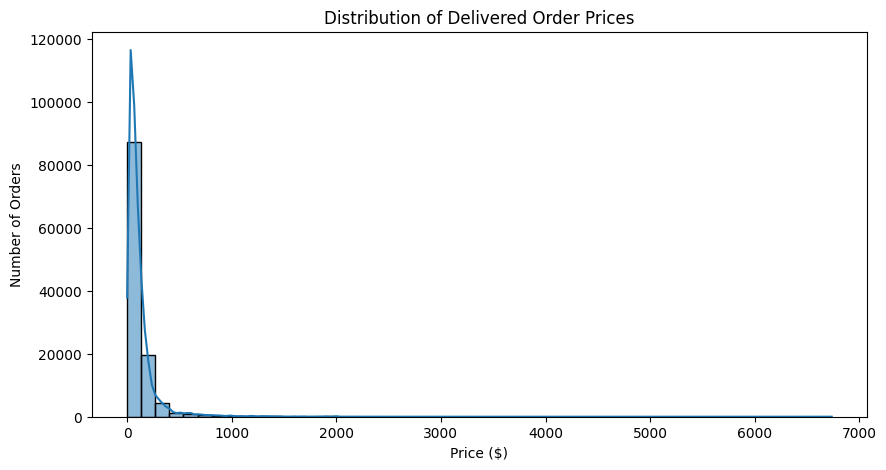

In [ ]:
total_sales = df_delivered['price'].sum()
avg_order_value = df_delivered['price'].mean()

# Histogram of prices
plt.figure(figsize=(10,5))
sns.histplot(df_delivered['price'], bins=50, kde=True, color="#1f77b4")
plt.title("Distribution of Delivered Order Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Orders")
plt.show()

Why: To measure overall revenue performance and customer spending per order.

Insight: It reveals how much total sales the business generates and the typical value of each purchase.

Business Value: Helps the business track financial growth, set pricing strategies, and identify whether to focus on increasing order volume or boosting average order value.

# **Top 10 Product Categories**

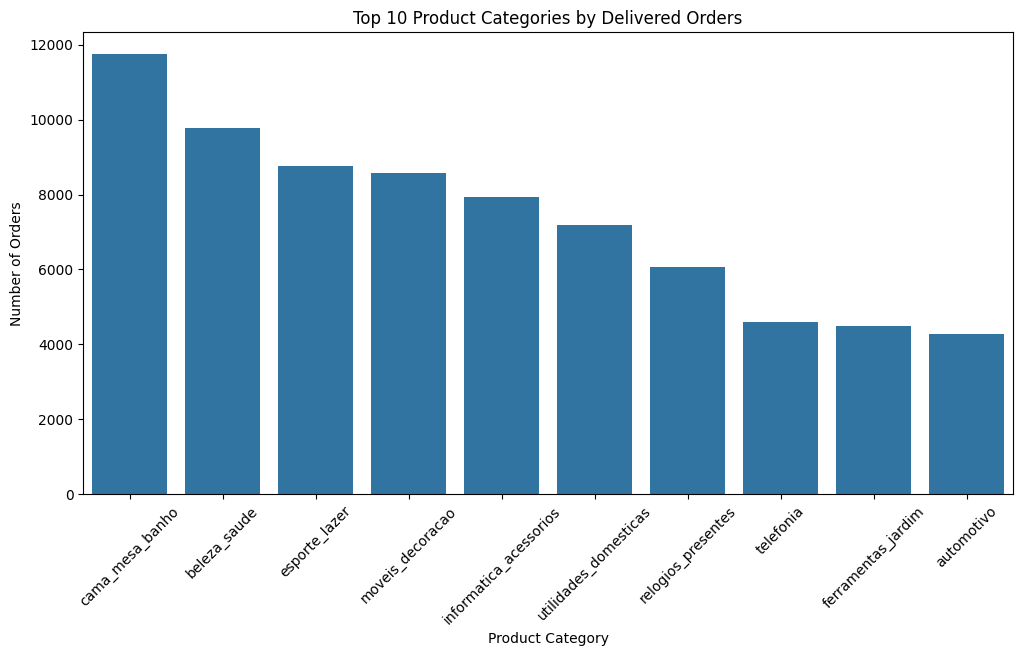

In [ ]:
# Prepare data as DataFrame
top_categories = df_delivered['product_category_name'].value_counts().head(10)

top_categories_df = top_categories.reset_index()
top_categories_df.columns = ['product_category', 'num_orders']

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_categories_df,
    x='product_category',
    y='num_orders',
    color="#1f77b4"  # single color for all bars
)
plt.title("Top 10 Product Categories by Delivered Orders")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

Why: To identify the most demanded product categories.

Insight: A few categories dominate total order volume, indicating concentrated customer demand.

Business Value: Helps prioritize stock, supplier partnerships, and promotional focus.

# **Monthly Sales Trend**

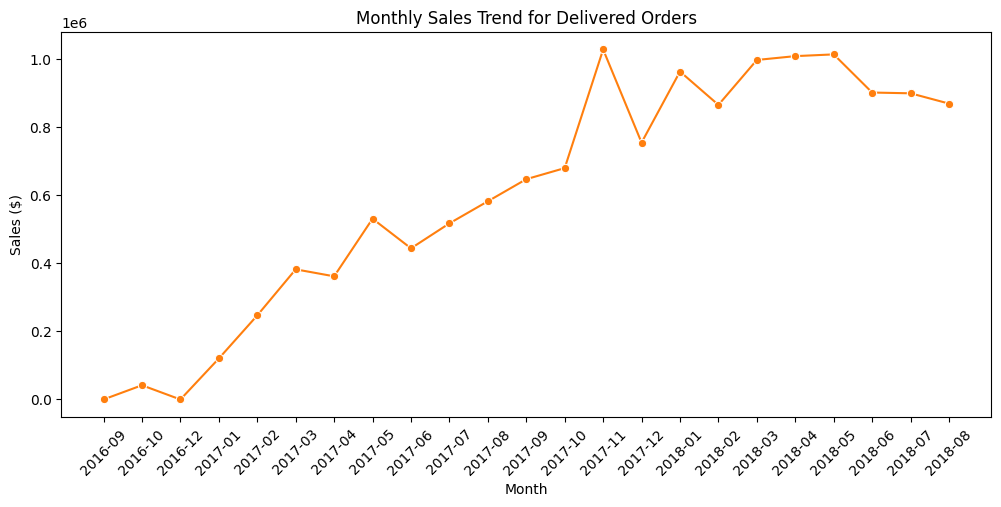

In [ ]:
df_delivered['month'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')
monthly_sales = df_delivered.groupby('month')['price'].sum().reset_index()
monthly_sales['month'] = monthly_sales['month'].astype(str)  # convert for plotting

plt.figure(figsize=(12,5))
sns.lineplot(
    data=monthly_sales,
    x='month',
    y='price',
    marker='o',
    color="#ff7f0e"
)
plt.title("Monthly Sales Trend for Delivered Orders")
plt.ylabel("Sales ($)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.show()

Why: To analyze revenue changes over time and detect seasonality.

Insight: Sales show clear fluctuations with peak periods indicating high demand months.

Business Value: Supports forecasting, marketing timing, and inventory planning.

# **Top 10 States by Revenue**

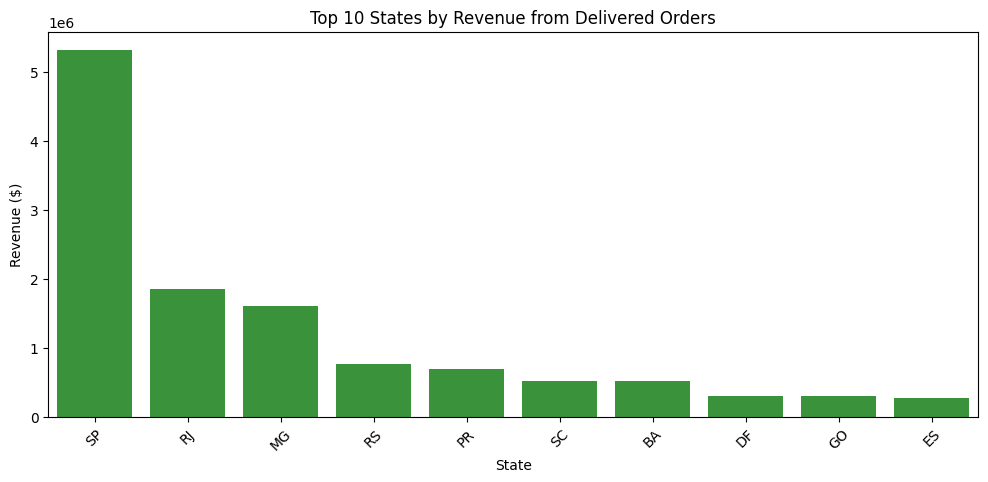

In [ ]:
state_sales = df_delivered.groupby('customer_state')['price'].sum().sort_values(ascending=False).head(10).reset_index()
state_sales.columns = ['customer_state', 'revenue']

plt.figure(figsize=(12,5))
sns.barplot(
    data=state_sales,
    x='customer_state',
    y='revenue',
    color="#2ca02c"
)
plt.title("Top 10 States by Revenue from Delivered Orders")
plt.xlabel("State")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.show()

Why: To evaluate geographical revenue distribution.

Insight: Revenue is concentrated in specific states, showing strong regional markets.

Business Value: Guides regional marketing strategy and logistics optimization.

# **Payment Type Distribution**

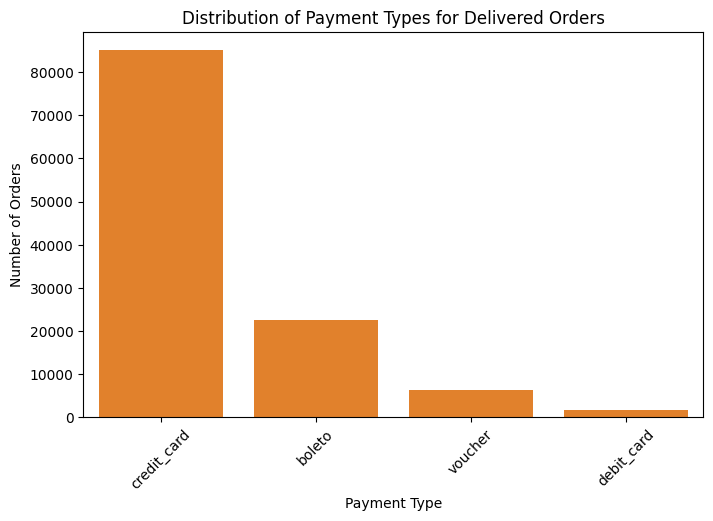

In [ ]:
# Payment type counts
payment_counts = df_delivered['payment_type'].value_counts().reset_index()
payment_counts.columns = ['payment_type', 'count']

plt.figure(figsize=(8,5))
sns.barplot(
    data=payment_counts,
    x='payment_type',
    y='count',
    color="#ff7f0e"
)
plt.title("Distribution of Payment Types for Delivered Orders")
plt.xlabel("Payment Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

Why: To examine customer payment preferences.

Insight: Certain payment methods dominate, indicating customer trust and convenience patterns.

Business Value: Helps optimize checkout systems and focus promotions on preferred payment methods.

# **Average Review Score by Product Category**

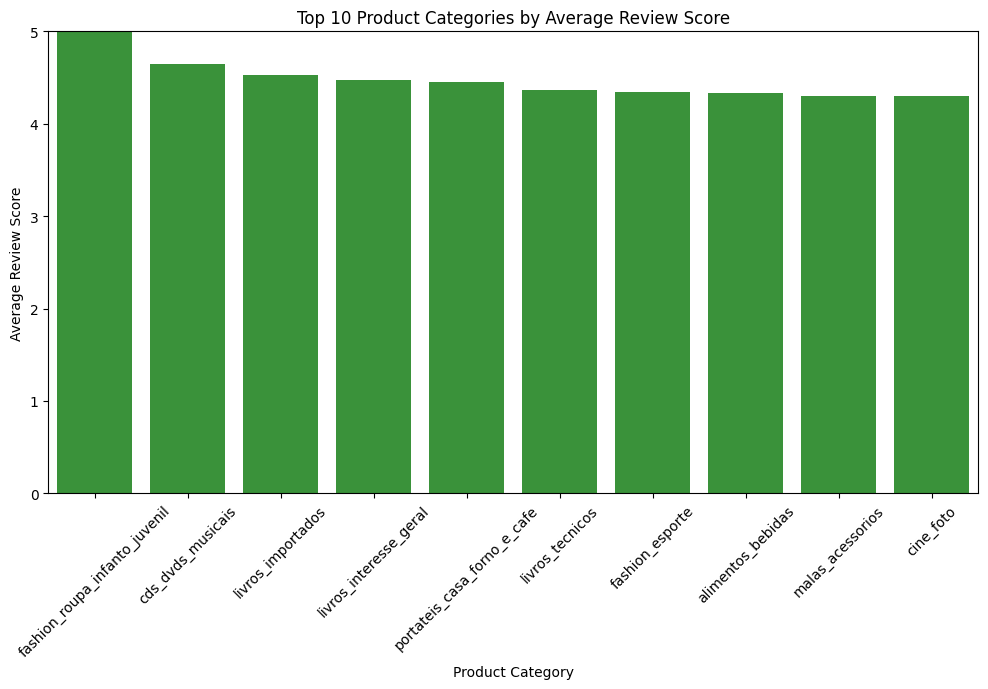

In [ ]:
avg_review_category = df_delivered.groupby('product_category_name')['review_score'].mean().sort_values(ascending=False).head(10).reset_index()
avg_review_category.columns = ['product_category', 'avg_review']

plt.figure(figsize=(12,6))
sns.barplot(
    data=avg_review_category,
    x='product_category',
    y='avg_review',
    color="#2ca02c"
)
plt.title("Top 10 Product Categories by Average Review Score")
plt.xlabel("Product Category")
plt.ylabel("Average Review Score")
plt.xticks(rotation=45)
plt.ylim(0,5)
plt.show()

Why: To measure customer satisfaction across product categories.

Insight: Some categories consistently receive higher ratings, while others underperform.

Business Value: Enables quality improvement focus and strategic promotion of high-rated categories.

# **Final Summary**

The analysis focused on delivered orders to ensure accurate revenue insights. Results show that a small number of product categories contribute a major share of total sales, indicating a concentrated revenue structure. Monthly sales trends reveal consistent growth patterns with noticeable peak periods, highlighting seasonal purchasing behavior. Geographic analysis shows that certain states generate significantly higher revenue, suggesting strong regional demand. Additionally, variations in average order value indicate opportunities to increase profitability through pricing and bundling strategies. Overall, the findings help the business identify high-performing categories, optimize marketing focus, and improve inventory planning based on actual purchasing trends.
